# Supplementary File S3 — Lesson Plan 2: The Bias-Variance Trade-off in Practice

**Estimated time:** 3 hours (2.5 hr lab + 30 min debrief)  
**Prerequisites:** Lesson Plan 1 (S2); basic familiarity with neural network training;
GPU access (free Google Colab T4 runtime is sufficient).  
**Materials:** Reuses the resized image cache and split from the S1 training notebook
(`MyDrive/CEP_Food_Dataset/resized_256.zip`). Trains three models of different capacity
and saves a `training_log_<model>.csv` for each to `MyDrive/CEP_Food_Dataset/outputs/`.

## Learning Objectives
- Train models of different capacities.
- Plot and interpret learning curves.
- Define underfitting, overfitting, and the optimal-capacity point.
- Connect empirical results to the bias-variance decomposition (Hastie, Tibshirani, and
  Friedman 2009, Chapter 7).


---
## Step 1 (15 min): Predict Before You Train

Review the bias-variance decomposition before running any code.

**Discussion:**
1. Which of the three model capacities below do you predict will generalize *best* to the
   test set, and why?
   - (a) A linear classifier on top of a frozen ResNet-50 backbone (lowest capacity)
   - (b) A fine-tuned ResNet-50 backbone alone (medium capacity)
   - (c) The full hybrid CNN-Transformer from S1 (highest capacity)
2. Which do you predict will show the largest train-test accuracy gap?


---
## Setup: mount Drive and reuse the S1 data cache

In [ ]:
# --- Imports + mount Drive ---
import os, time, zipfile
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

try:
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.ismount('/content/drive'), 'Drive not mounted — re-run this cell.'
except ModuleNotFoundError:
    pass  # running locally

DRIVE_PROJECT = '/content/drive/MyDrive/CEP_Food_Dataset'
OUTPUTS       = f'{DRIVE_PROJECT}/outputs'
ZIP_DRIVE     = f'{DRIVE_PROJECT}/resized_256.zip'
RESIZED_DIR   = '/content/resized_256'
os.makedirs(OUTPUTS, exist_ok=True)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS     = 15      # shorter than the full S1 run (50) -- enough to see the trade-off
BATCH_SIZE = 64
LR         = 1e-4
print(f"Device: {DEVICE}")


Mounted at /content/drive
Device: cuda


In [ ]:
import zipfile
RESIZED_DIR = "/content/resized_256"
with zipfile.ZipFile(ZIP_DRIVE) as z:
    z.extractall(RESIZED_DIR)
print(len([d for d in os.listdir(RESIZED_DIR) if os.path.isdir(f"{RESIZED_DIR}/{d}")]), "classes")

100 classes


In [ ]:
# --- Pull the resized cache from Drive and rebuild the SAME split as S1 ---
if not os.path.isdir(RESIZED_DIR) or len(os.listdir(RESIZED_DIR)) == 0:
    assert os.path.exists(ZIP_DRIVE), (
        f'Cache not found: {ZIP_DRIVE}\nRun the S1 training notebook first — it builds this zip.')
    t = time.time()
    with zipfile.ZipFile(ZIP_DRIVE) as z: z.extractall('/content')
    print(f'Extracted cache in {time.time()-t:.0f}s')

paths, labels, class_names = [], [], []
for idx, cls in enumerate(sorted(os.listdir(RESIZED_DIR))):
    cp = os.path.join(RESIZED_DIR, cls)
    if not os.path.isdir(cp): continue
    class_names.append(cls)
    for f in os.listdir(cp):
        paths.append(os.path.join(cp, f)); labels.append(idx)

NUM_CLASSES = len(class_names)   # derived from YOUR data, not hardcoded

# identical stratified 70/15/15 split (same random_state as S1)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.3,
                                            random_state=42, stratify=labels)
X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                              random_state=42, stratify=y_tmp)
print(f'{len(paths):,} images | {NUM_CLASSES} classes | '
      f'train {len(X_tr):,} | val {len(X_val):,} | test {len(X_tst):,}')


4,577 images | 100 classes | train 3,203 | val 687 | test 687


In [ ]:
# --- Fast transforms + loaders (cached 256px imgs, AMP-ready, safe worker count) ---
_m, _s = [0.485,0.456,0.406], [0.229,0.224,0.225]
tr_tfm = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
                             transforms.RandomHorizontalFlip(),
                             transforms.ToTensor(), transforms.Normalize(_m, _s)])
val_tfm = transforms.Compose([transforms.Resize((224,224)),
                              transforms.ToTensor(), transforms.Normalize(_m, _s)])

class FoodDS(Dataset):
    def __init__(self, paths, labels, tfm=None):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return (self.tfm(img) if self.tfm else img), self.labels[i]

train_loader = DataLoader(FoodDS(X_tr, y_tr, tr_tfm), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(FoodDS(X_val, y_val, val_tfm), batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
print(f'Loaders: {len(train_loader)} train / {len(val_loader)} val batches')


Loaders: 51 train / 6 val batches


---
## Step 2 (60 min): Train Three Model Variants

Each variant is trained on the same data split, for the same number of epochs, and its
training/validation accuracy is logged every epoch.


### (a) Linear classifier on a frozen ResNet-50 backbone (high bias, low variance)

In [ ]:
# Model A: frozen ResNet-50 features + a single trainable linear layer.
# Wrapping the frozen backbone means it accepts images like B and C (uniform training loop).
# Only the linear head has trainable params -> this is the low-capacity variant.
class FrozenClassifier(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        try:    bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        except: bb = models.resnet50(pretrained=True)
        bb.fc = nn.Identity()
        for p in bb.parameters(): p.requires_grad = False
        self.backbone = bb
        self.head = nn.Linear(2048, n_cls)
    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()   # keep frozen BatchNorm stats fixed even in train mode
        return self
    def forward(self, x):
        with torch.no_grad():
            f = self.backbone(x)
        return self.head(f)

model_a = FrozenClassifier(NUM_CLASSES).to(DEVICE)
trainable_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A (frozen features + linear head): {trainable_a:,} trainable params")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 43.0MB/s]


Model A (frozen features + linear head): 204,900 trainable params


### (b) Fine-tuned ResNet-50 backbone alone (medium capacity)

In [ ]:
try:    model_b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
except: model_b = models.resnet50(pretrained=True)
model_b.fc = nn.Linear(model_b.fc.in_features, NUM_CLASSES)
model_b = model_b.to(DEVICE)
print(f"Model B (ResNet-50 fine-tuned): {sum(p.numel() for p in model_b.parameters()):,} params")


Model B (ResNet-50 fine-tuned): 23,712,932 params


### (c) Full hybrid CNN-Transformer (high capacity) — architecture from S1

In [ ]:
class PE(nn.Module):
    def __init__(self, c, d): super().__init__(); self.p = nn.Conv2d(c, d, 1, 1)
    def forward(self, x): return self.p(x).flatten(2).transpose(1, 2)

class TB(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.a = nn.MultiheadAttention(d, h, 0.1)
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.m = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4, d), nn.Dropout(0.1))
    def forward(self, x):
        xn = self.n1(x).transpose(0, 1)
        a, _ = self.a(xn, xn, xn)
        x = x + a.transpose(0, 1)
        return x + self.m(self.n2(x))

class HybridModel(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        try:    bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        except: bb = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(bb.children())[:-2])
        self.pe = PE(2048, 768)
        with torch.no_grad():
            o = self.cnn(torch.randn(1, 3, 224, 224)); n_patches = o.shape[2]*o.shape[3]
        self.cls_t = nn.Parameter(torch.randn(1, 1, 768))
        self.pos = nn.Parameter(torch.randn(1, n_patches+1, 768))
        self.d = nn.Dropout(0.1)
        self.t = nn.ModuleList([TB(768, 12) for _ in range(6)])
        self.n = nn.LayerNorm(768)
        self.h = nn.Sequential(nn.Linear(768, 384), nn.GELU(), nn.Dropout(0.1), nn.Linear(384, n_cls))
    def forward(self, x):
        B = x.shape[0]
        x = self.pe(self.cnn(x))
        x = torch.cat([self.cls_t.expand(B, -1, -1), x], 1) + self.pos
        x = self.d(x)
        for t in self.t: x = t(x)
        return self.h(self.n(x[:, 0]))

model_c = HybridModel(NUM_CLASSES).to(DEVICE)
print(f"Model C (hybrid CNN-Transformer): {sum(p.numel() for p in model_c.parameters()):,} params")


Model C (hybrid CNN-Transformer): 67,983,396 params


In [ ]:
# --- Training utilities (mixed precision -> fast on the T4) ---
def train_epoch(m, ld, crit, opt, scaler, dev):
    m.train(); ls=cor=tot=0
    for im, lb in tqdm(ld, desc='train', leave=False):
        im, lb = im.to(dev, non_blocking=True), lb.to(dev, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            o = m(im); l = crit(o, lb)
        scaler.scale(l).backward(); scaler.step(opt); scaler.update()
        ls += l.item()*im.size(0); cor += (o.argmax(1)==lb).sum().item(); tot += lb.size(0)
    return ls/tot, 100.*cor/tot

def validate(m, ld, crit, dev):
    m.eval(); ls=cor=tot=0
    with torch.no_grad():
        for im, lb in ld:
            im, lb = im.to(dev, non_blocking=True), lb.to(dev, non_blocking=True)
            with torch.cuda.amp.autocast():
                o = m(im); l = crit(o, lb)
            ls += l.item()*im.size(0); cor += (o.argmax(1)==lb).sum().item(); tot += lb.size(0)
    return ls/tot, 100.*cor/tot

def run_training(model, model_name, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    # only optimize params that require grad (matters for Model A's frozen backbone)
    params = [p for p in model.parameters() if p.requires_grad]
    crit = nn.CrossEntropyLoss()
    opt = optim.AdamW(params, lr=lr, weight_decay=0.01)
    scaler = torch.cuda.amp.GradScaler()
    hist = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for e in range(1, epochs+1):
        t0 = time.time()
        trl, tra = train_epoch(model, train_loader, crit, opt, scaler, DEVICE)
        vl, va   = validate(model, val_loader, crit, DEVICE)
        for k, v in zip(hist, [e, trl, tra, vl, va]): hist[k].append(v)
        print(f"[{model_name}] Epoch {e:>2}/{epochs} - Train {tra:5.2f}% | Val {va:5.2f}% | {time.time()-t0:4.0f}s")
    log_df = pd.DataFrame(hist)
    out = f"{OUTPUTS}/training_log_{model_name}.csv"
    log_df.to_csv(out, index=False)
    print(f"  saved -> {out}")
    return log_df

torch.backends.cudnn.benchmark = True
print('Training utilities ready.')


Training utilities ready.


In [ ]:
# --- Train all three (each saves training_log_<name>.csv to Drive) ---
log_a = run_training(model_a, 'model_a', train_loader, val_loader)
log_b = run_training(model_b, 'model_b', train_loader, val_loader)
log_c = run_training(model_c, 'model_c', train_loader, val_loader)


/tmp/ipykernel_571/3247012860.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


train:   0%|          | 0/51 [00:00<?, ?it/s]

/tmp/ipykernel_571/3247012860.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_571/3247012860.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[model_a] Epoch  1/15 - Train  5.03% | Val 10.48% |   20s


train:   0%|          | 0/51 [00:00<?, ?it/s]

...

[model_c] Epoch 13/15 - Train 98.88% | Val 90.10% |   21s


train:   0%|          | 0/51 [00:00<?, ?it/s]

[model_c] Epoch 14/15 - Train 98.53% | Val 89.23% |   21s


train:   0%|          | 0/51 [00:00<?, ?it/s]

[model_c] Epoch 15/15 - Train 97.75% | Val 89.37% |   22s
  saved -> /content/drive/MyDrive/CEP_Food_Dataset/outputs/training_log_model_c.csv


*(Each call saved a `training_log_<model_name>.csv` to your outputs folder — together these
three logs are the `training_log.csv` artifact referenced in Section 5.2.)*


---
## Step 3 (30 min): Plot Learning Curves for All Three Models


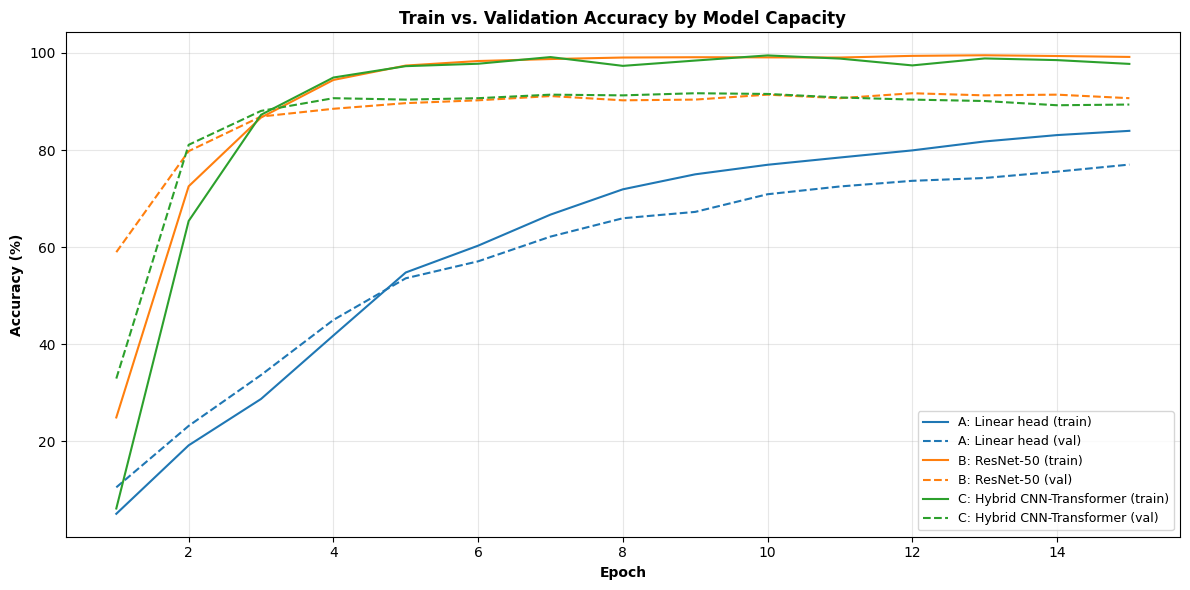

In [ ]:
# Reload from Drive (so this cell works in a fresh session too)
log_a = pd.read_csv(f'{OUTPUTS}/training_log_model_a.csv')
log_b = pd.read_csv(f'{OUTPUTS}/training_log_model_b.csv')
log_c = pd.read_csv(f'{OUTPUTS}/training_log_model_c.csv')

fig, ax = plt.subplots(figsize=(12, 6))
for log, label, color in [(log_a, 'A: Linear head', 'tab:blue'),
                          (log_b, 'B: ResNet-50', 'tab:orange'),
                          (log_c, 'C: Hybrid CNN-Transformer', 'tab:green')]:
    ax.plot(log['epoch'], log['train_acc'], color=color, linestyle='-',  label=f'{label} (train)')
    ax.plot(log['epoch'], log['val_acc'],   color=color, linestyle='--', label=f'{label} (val)')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Train vs. Validation Accuracy by Model Capacity', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/bias_variance_curves.png', dpi=200, bbox_inches='tight')
plt.show()


**Identify** the epoch at which each model begins to overfit (train accuracy continuing
to rise while validation accuracy plateaus or falls), if at all.


---
## Step 4 (25 min): Quantify the Train-Test Gap

In [ ]:
gap_table = pd.DataFrame({
    'Model': ['A: Linear head', 'B: ResNet-50', 'C: Hybrid CNN-Transformer'],
    'Final Train Acc (%)': [log_a['train_acc'].iloc[-1], log_b['train_acc'].iloc[-1], log_c['train_acc'].iloc[-1]],
    'Final Val Acc (%)':   [log_a['val_acc'].iloc[-1],   log_b['val_acc'].iloc[-1],   log_c['val_acc'].iloc[-1]],
})
gap_table['Train-Val Gap (pp)'] = gap_table['Final Train Acc (%)'] - gap_table['Final Val Acc (%)']
gap_table

,Model,Final Train Acc (%),Final Val Acc (%),Train-Val Gap (pp)
0,A: Linear head,83.952544,77.001456,6.951089
1,B: ResNet-50,99.188261,90.684134,8.504127
2,C: Hybrid CNN-Transformer,97.752107,89.374090,8.378017


**Note:** in the full 50-epoch benchmark run (S1), the full hybrid model reaches a high
training accuracy and a lower test accuracy — a multi-point gap (Section 5.2). Compare your
(shorter, 15-epoch) run's gap for Model C to your own S1 result, and discuss whether it is
trending toward a similar pattern.

**Discuss:** does the high-capacity model (C) have the largest train-val gap? Does this
constitute *harmful* overfitting, given its absolute validation accuracy?


---
## Debrief (30 min)

- Is a large train-test gap acceptable? When would it not be?
- How does dataset size affect the gap? (Your dataset is small — ~46 images/class — so
  expect the high-capacity model to overfit readily.)
- What interventions (early stopping, weight decay, dropout) would reduce the gap, and at
  what cost?

---
## Assessment

**One-page written analysis:** Describe the bias-variance trade-off observed in your
experiment. Identify which model capacity you would recommend deploying, and why. Propose
one additional regularization strategy you would test.

*(Rubric: see Supplementary File S7.)*
